"""
rc_plot.py — Step 2: Plot from rc_papers.csv
=============================================
Produces TWO figures:
  1. rc_landscape.png            — absolute publication counts
  2. rc_landscape_normalized.png — fractional / 100% stacked

Landmark ★ markers are placed INSIDE their subfield band,
vertically centred on the band at the paper's year.
Annotations point upward above the total stack to avoid overlap.

pip install matplotlib numpy
python rc_plot.py
"""

In [1]:
import csv, re, sys
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

1. Config

In [64]:
INPUT_CSV    = "rc_papers.csv"
LANDMARK_CSV = "rc_landmark_papers.csv"
OUTPUT_ABS   = "rc_landscape.png"
OUTPUT_NORM  = "rc_landscape_normalized.png"
YEARS        = (2001, 2026)

###putting more bright and distinct colors for better visibility and differentiation of subfields in the plots
SUBFIELD_COLORS = {
    "Photonics & Optics":          "red",
    "Physical & Hardware RC":     "green",
    "Quantum RC":                 "blue",
    "Nonlinear Dynamics & Chaos": "orange",
    "Neuroscience & Comp. Neuro": "royalblue",
    "Mathematics & Theory":       "black",
    "Signal Processing & Comms":  "darkviolet",
    "Control & Robotics":         "c",
    "Climate & Earth Sciences":   "brown",
    "ML / Next-Gen RC":           "pink",
    "General RC / ESN Methods":   "dimgray",
}

# SUBFIELD_COLORS = {
#     "Photonics & Optics":           "#f4a261",
#     "Physical & Hardware RC":       "#e76f51",
#     "Quantum RC":                   "#9b5de5",
#     "Nonlinear Dynamics & Chaos":   "#2a9d8f",
#     "Neuroscience & Comp. Neuro":   "#457b9d",
#     "Mathematics & Theory":         "#1d3557",
#     "Signal Processing & Comms":    "#606c38",
#     "Control & Robotics":           "#bc6c25",
#     "Climate & Earth Sciences":     "#52b788",
#     "ML / Next-Gen RC":             "#e9c46a",
#     "General RC / ESN Methods":     "#a8dadc",
#     "Other / Interdisciplinary":    "#888888",
# }
SUBFIELD_ORDER = list(SUBFIELD_COLORS.keys())

4. Helper funcss

In [ ]:
def load_csv(path, required=True):
    try:
        with open(path, newline="", encoding="utf-8") as f:
            return list(csv.DictReader(f))
    except FileNotFoundError:
        if required:
            print(f"ERROR: '{path}' not found."); sys.exit(1)
        return []


def norm_title(t):
    return re.sub(r"[^a-z0-9]", "", (t or "").lower())[:60]


def load_landmarks(papers, landmark_csv):
    """
    Match landmark CSV rows against harvested papers by normalised title.
    Unmatched rows (tech reports not in OpenAlex) are injected directly.
    Falls back to 'landmark' column in rc_papers.csv if no separate file.
    """
    lm_rows = load_csv(landmark_csv, required=False)

    if not lm_rows:
        print(f"  No '{landmark_csv}' — using 'landmark' column in rc_papers.csv")
        return [p for p in papers if p.get("landmark", "").strip()]

    index = {norm_title(p.get("title", "")): p for p in papers}
    matched, unmatched = [], []

    for row in lm_rows:
        key = norm_title(row.get("title", ""))
        if key in index:
            p = index[key]
            p["landmark"]           = row.get("landmark", "")
            p["landmark_subfield"]  = row.get("subfield", p.get("subfield", ""))
            p["landmark_authors"]   = row.get("authors", "")
            matched.append(p)
        else:
            unmatched.append({
                "title":            row.get("title", ""),
                "year":             row.get("year", ""),
                "citationCount":    9999,
                "cites_per_year":   999,
                "subfield":         row.get("subfield", "General RC / ESN Methods"),
                "landmark":         row.get("landmark", ""),
                "landmark_subfield":row.get("subfield", "General RC / ESN Methods"),
                "landmark_authors":  row.get("authors", ""),
            })

    print(f"  Matched  : {len(matched)}")
    if unmatched:
        print(f"  Injected : {len(unmatched)}  (not in harvested dataset)")
        for u in unmatched:
            print(f"    {u['year']}  {u['title'][:60]}")

    return matched + unmatched

# ══════════════════════════════════════════════════════════════════════
# DATA MATRIX
# ══════════════════════════════════════════════════════════════════════

def build_matrix(papers, order, years):
    counts = {sf: defaultdict(int) for sf in order}
    for p in papers:
        y  = p.get("year")
        sf = (p.get("subfield") or "").strip() or "Other / Interdisciplinary"
        try: y = int(y)
        except (TypeError, ValueError): continue
        if YEARS[0] <= y <= YEARS[1]:
            counts[sf][y] += 1
    return np.array([[counts[sf].get(y, 0) for y in years]
                     for sf in order], dtype=float)

# ══════════════════════════════════════════════════════════════════════
# LANDMARK PLACEMENT — inside subfield band, annotations above stack
# ══════════════════════════════════════════════════════════════════════

def place_landmarks(ax, landmarks, order, matrix, years, totals, normalised):
    """
    For each landmark:
      - compute the y-midpoint of its subfield band at that year
      - draw a white ★ with a coloured edge matching the subfield
      - draw a short annotation box above the top of the stack
    """
    col_total = np.where(totals > 0, totals, 1.0)

    # group landmarks by (subfield, year) to handle vertical stacking
    groups = defaultdict(list)
    for p in landmarks:
        try: yr = int(p.get("year"))
        except (TypeError, ValueError): continue
        if not (YEARS[0] <= yr <= YEARS[1]): continue
        sf = (p.get("landmark_subfield") or p.get("subfield") or
              "General RC / ESN Methods")
        groups[(sf, yr)].append(p)

    # we need a y-offset per year to stagger annotation boxes horizontally
    ann_yr_count = defaultdict(int)
    used_ann_y_by_year = defaultdict(list)

    for (sf, yr), group in sorted(groups.items(),
                                   key=lambda kv: kv[0][1]):
        idx = yr - years[0]
        if idx < 0 or idx >= matrix.shape[1]:
            continue

        # ── compute band bottom and top ───────────────────────────────
        bottom = 0.0
        band_b = band_t = None
        for i, s in enumerate(order):
            h = matrix[i, idx] / col_total[idx] if normalised else matrix[i, idx]
            if s == sf:
                band_b = bottom
                band_t = bottom + h
                break
            bottom += h

        if band_b is None or (band_t - band_b) < 1e-6:
            continue   # subfield absent this year

        band_h   = band_t - band_b
        n_in_grp = len(group)
        sf_color = SUBFIELD_COLORS.get(sf, "#FFD700")

        stack_top = (totals[idx] / col_total[idx]) if normalised else totals[idx]

        for k, p in enumerate(sorted(group,
                                     key=lambda x: -(float(x.get("cites_per_year") or 0)))):
            # vertical position inside band: evenly distribute
            frac  = (k + 0.5) / n_in_grp
            ystar = band_b + frac * band_h

            # ── star marker ───────────────────────────────────────────
            ax.plot(yr, ystar, marker="*", color="black",
                    markersize=16, zorder=12,
                    markeredgecolor=sf_color, markeredgewidth=0.8)

            # ── annotation above the stack ────────────────────────────
            # stagger horizontally to avoid overlap for same-year landmarks
            ann_n = ann_yr_count[yr]
            ann_yr_count[yr] += 1

            if normalised:
                ann_y   = min(0.98, ystar + 0.05 + ann_n * 0.03)
                x_shift = 0.15 + ann_n * 0.4
            else:
                headroom = stack_top * 0.06
                ann_y    = stack_top + headroom + ann_n * stack_top * 0.08
                x_shift  = 0.15 + ann_n * 0.5

            title_s = (p.get("title") or "")[:36]
            reason  = (p.get("landmark") or "").strip()[:40]

            ax.annotate(
                f"{title_s}\n{reason}",
                xy=(yr, ystar),
                xytext=(yr + x_shift, ann_y),
                fontsize=14, color=sf_color, alpha=0.95, zorder=13,
                va="bottom", ha="left",
                arrowprops=dict(arrowstyle="-", color=sf_color,
                                alpha=0.45, lw=0.55,
                                connectionstyle="arc3,rad=0.1"),
                bbox=dict(boxstyle="round,pad=0.22", fc="white",
                          ec=sf_color, alpha=0.85, lw=0.6),
            )

# ══════════════════════════════════════════════════════════════════════
# BAND LABELS (right edge)
# ══════════════════════════════════════════════════════════════════════

def draw_band_labels(ax, order, matrix, totals, years, normalised):
    col_total = np.where(totals > 0, totals, 1.0)
    cum = np.zeros(matrix.shape[1])
    for i, sf in enumerate(order):
        heights = matrix[i] / col_total if normalised else matrix[i]
        mid_y   = cum[-1] + heights[-1] / 2.0
        thresh  = 0.03 if normalised else totals[-1] * 0.03
        if matrix[i].sum() > 0 and heights[-1] > thresh:
            ax.text(years[-1] + 0.3, mid_y, sf,
                    fontsize=24, color="black", va="center", alpha=0.9)
        cum += heights

# ══════════════════════════════════════════════════════════════════════
# SHARED STYLE
# ══════════════════════════════════════════════════════════════════════

def _style(ax):
    ax.tick_params(colors="black", labelsize=12)
    ax.set_xticks(range(YEARS[0], YEARS[1] + 1, 2))
    for spine in ax.spines.values():
        spine.set_edgecolor("#666")
    ax.yaxis.grid(False, color="#d0d0d0", lw=0.5, zorder=0)
    ax.set_axisbelow(True)


def _legend(ax, order, matrix, totals, normalised):
    thresh = 0.03 if normalised else (totals[-1] * 0.03 if totals[-1] else 0)
    handles = [
        mpatches.Patch(color=SUBFIELD_COLORS.get(sf, "#aaa"),
                       label=sf, alpha=0.88)
        for i, sf in enumerate(order)
        if matrix[i].sum() > 0 and matrix[i, -1] <= thresh
    ]
    handles.append(
        plt.Line2D([0], [0], marker="*", color="black", markersize=12,
                   lw=0, markeredgecolor="#FFD700", markeredgewidth=0.8,
                   label="Landmark (in band)"),
    )
    ax.legend(handles=handles, loc="upper left", fontsize=11,
              framealpha=0.85, facecolor="white", edgecolor="#999",
              ncol=1, labelcolor="black", borderpad=0.8)

# ══════════════════════════════════════════════════════════════════════
# FIGURE 1 — ABSOLUTE
# ══════════════════════════════════════════════════════════════════════

def plot_absolute(papers, landmarks, order, matrix, years, totals):
    fig, ax = plt.subplots(figsize=(24, 12))

    colors = [SUBFIELD_COLORS.get(sf, "#aaaaaa") for sf in order]
    ax.stackplot(years, matrix, colors=colors, alpha=0.88, linewidth=0)
    ax.plot(years, totals, color="black", lw=1.8,
            linestyle="--", alpha=0.5, zorder=5)

    draw_band_labels(ax, order, matrix, totals, years, normalised=False)
    place_landmarks(ax, landmarks, order, matrix, years, totals,
                    normalised=False)

    # fixed origin annotations
    mid = float(np.mean(totals[1:5])) if len(totals) > 4 else 10.0
    ax.annotate("ESN (Jaeger 2001)\n+ LSM (Maass 2002)",
                xy=(2001.8, 3), xytext=(2003.5, mid * 0.6 + 8),
                fontsize=12, color="black", fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="black", lw=1.1),
                bbox=dict(boxstyle="round", fc="white", ec="black", alpha=0.85))

    ymax = float(totals.max()) * 1.7 if totals.max() > 0 else 100
    ax.set_xlim(YEARS[0] - 0.5, YEARS[1] + 4.0)
    ax.set_ylim(0, ymax)
    ax.set_xlabel("Year", color="black", fontsize=18, labelpad=10)
    ax.set_ylabel("Publications per Year", color="black", fontsize=18, labelpad=10)
    _style(ax)
    _legend(ax, order, matrix, totals, normalised=False)

    plt.tight_layout()
    plt.savefig(OUTPUT_ABS, dpi=200, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"Saved -> '{OUTPUT_ABS}'")
    plt.show()

# ══════════════════════════════════════════════════════════════════════
# FIGURE 2 — NORMALISED
# ══════════════════════════════════════════════════════════════════════

def plot_normalised(papers, landmarks, order, matrix, years, totals):
    fig, ax = plt.subplots(figsize=(24, 18))

    col_total   = np.where(totals > 0, totals, 1.0)
    norm_matrix = matrix / col_total

    colors = [SUBFIELD_COLORS.get(sf, "#aaaaaa") for sf in order]
    ax.stackplot(years, norm_matrix, colors=colors, alpha=0.88, linewidth=0)

    draw_band_labels(ax, order, matrix, totals, years, normalised=True)
    place_landmarks(ax, landmarks, order, matrix, years, totals,
                    normalised=True)

    ax.set_yticks(np.linspace(0.0, 1.0, 6))
    ax.set_yticklabels([f"{v:.1f}" for v in np.linspace(0.0, 1.0, 6)])

    ax.set_xlim(YEARS[0] - 0.5, YEARS[1] + 4.0)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Year", color="black", fontsize=24, labelpad=10)
    ax.set_ylabel("Fraction of Publications", color="black", fontsize=24, labelpad=10)
    _style(ax)
    ###increase legend font size
    _legend(ax, order, norm_matrix, norm_matrix.sum(axis=0), normalised=True)
    leg = ax.get_legend()
    if leg is not None:
        for txt in leg.get_texts():
            txt.set_fontsize(18)

    plt.tight_layout()
    plt.savefig(OUTPUT_NORM, dpi=200, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"Saved -> '{OUTPUT_NORM}'")
    plt.show()


6,671 papers loaded from 'rc_papers.csv'

Loading landmarks from 'rc_landmark_papers.csv'...
  Matched  : 20
  Injected : 4  (not in harvested dataset)
    2001  The echo state approach to analysing and training recurrent 
    2004  Edge of chaos and prediction of computational performance fo
    2013  Parallel photonic information processing at gigabyte per sec
    2014  Separation of variables and universality in reservoir comput
Total landmarks : 24

── Subfield breakdown ──
  Photonics & Optics                             1185  ██████████████████
  Physical & Hardware RC                         1091  ████████████████
  Quantum RC                                      146  ██
  Nonlinear Dynamics & Chaos                     1051  ████████████████
  Neuroscience & Comp. Neuro                      261  ████
  Mathematics & Theory                            111  █
  Signal Processing & Comms                       225  ███
  Control & Robotics                              187  ██
  Clim

C:\Users\genxm\AppData\Local\Temp\ipykernel_29292\1394312330.py:191: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.yaxis.grid(False, color="#d0d0d0", lw=0.5, zorder=0)


Saved -> 'rc_landscape.png'


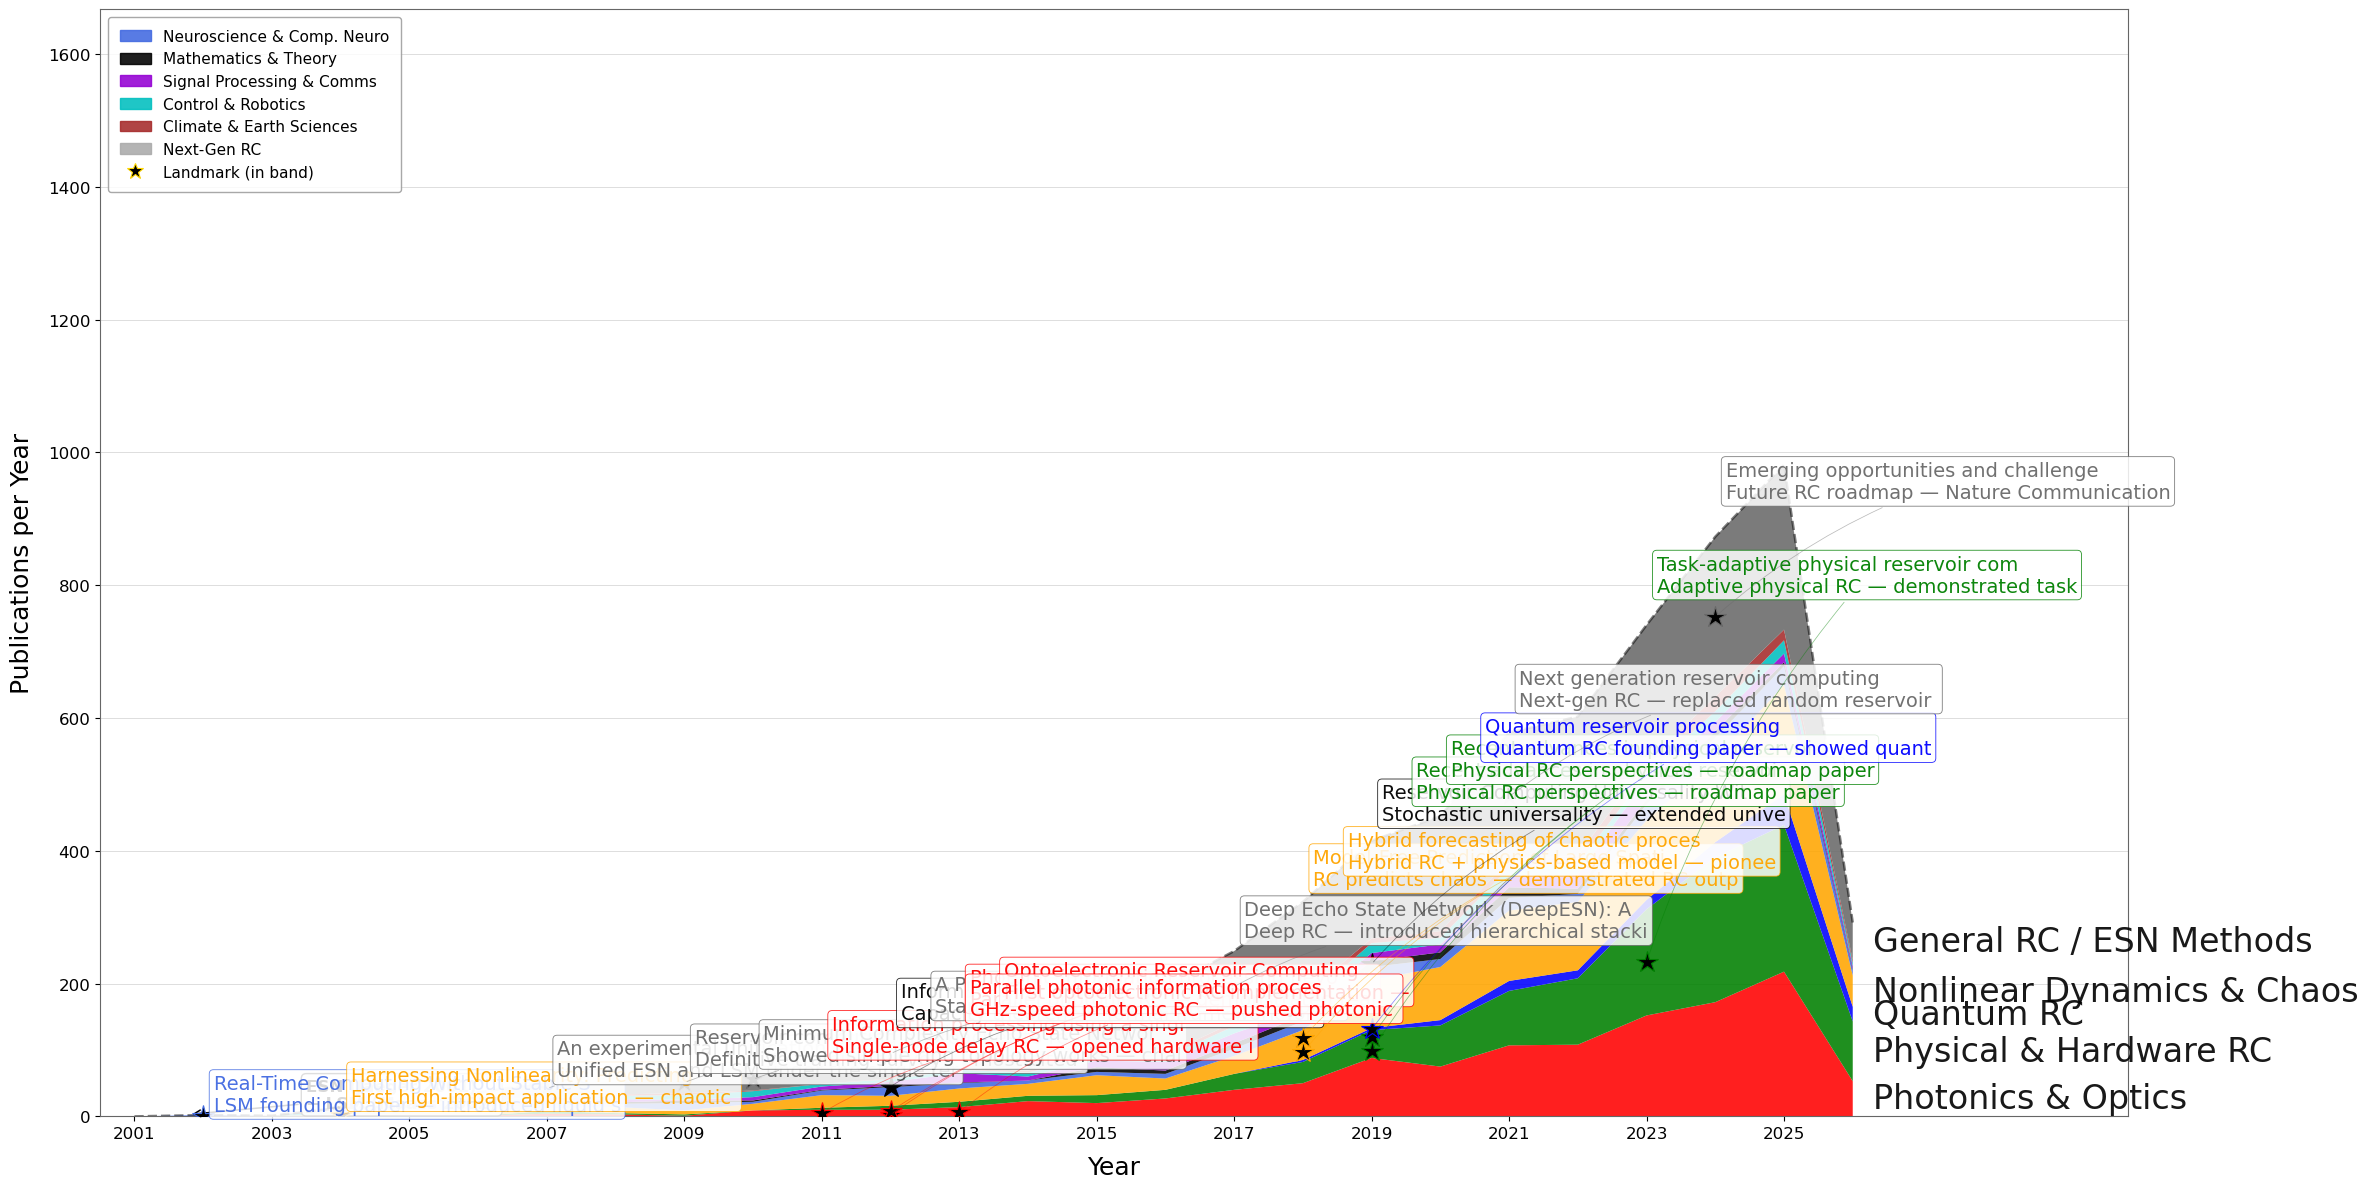


Plotting normalised figure...
Saved -> 'rc_landscape_normalized.png'


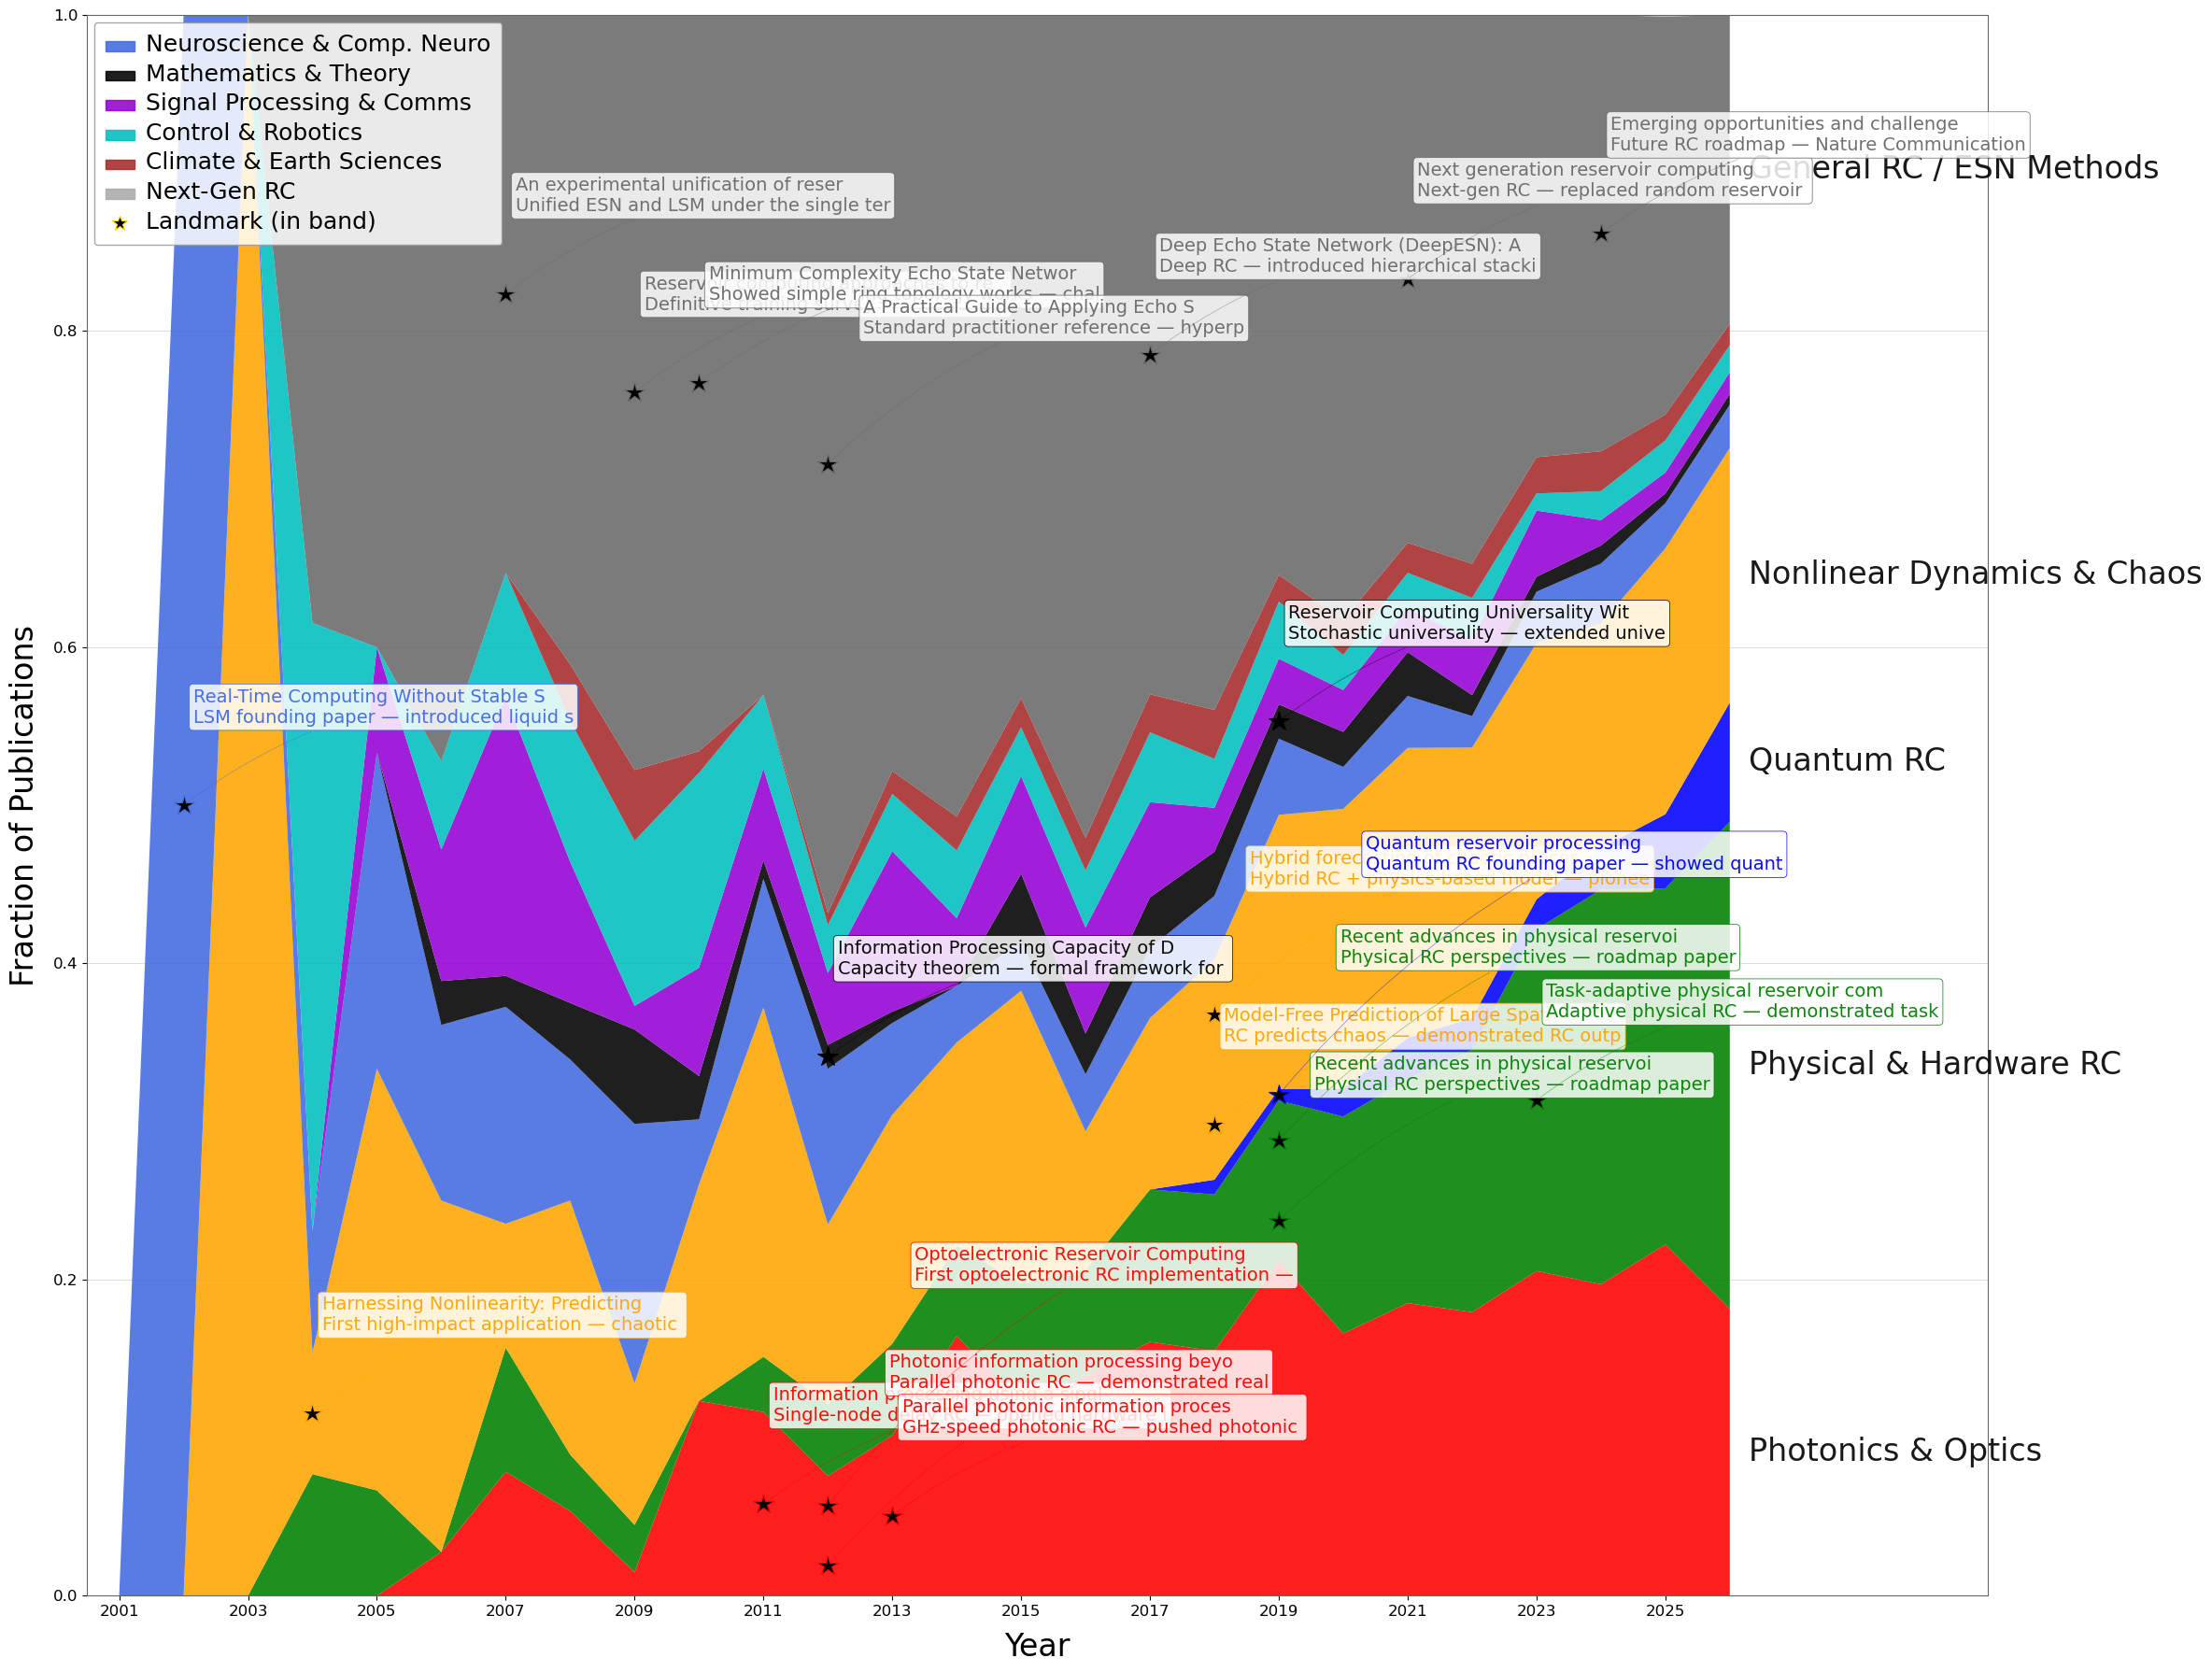

In [78]:
papers = load_csv(INPUT_CSV)
print(f"\n{len(papers):,} papers loaded from '{INPUT_CSV}'")

print(f"\nLoading landmarks from '{LANDMARK_CSV}'...")
landmarks = load_landmarks(papers, LANDMARK_CSV)
print(f"Total landmarks : {len(landmarks)}\n")

# extend order with any unknown subfields in CSV
all_sf = set(p.get("subfield", "") for p in papers)
order  = SUBFIELD_ORDER + sorted(
    sf for sf in all_sf if sf not in SUBFIELD_ORDER and sf)

years  = list(range(YEARS[0], YEARS[1] + 1))
matrix = build_matrix(papers, order, years)
totals = matrix.sum(axis=0)

print("── Subfield breakdown ──")
row_sums = matrix.sum(axis=1)
mx = row_sums.max() or 1
for i, sf in enumerate(order):
    n = int(row_sums[i])
    if n > 0:
        print(f"  {sf:<45} {n:>5}  {'█'*(n*35//int(mx))}")

print("\nPlotting absolute figure...")
plot_absolute(papers, landmarks, order, matrix, years, totals)

print("\nPlotting normalised figure...")
plot_normalised(papers, landmarks, order, matrix, years, totals)

In [ ]:
# New plotting helpers: keep original plots unchanged
EARLY_WINDOW_END = 2004
OUTPUT_ABS_EARLY = "rc_landscape_early_window.png"
OUTPUT_NORM_EARLY = "rc_landscape_early_window_normalized.png"

def year_bucket_early(y, early_end=EARLY_WINDOW_END):
    return early_end if y <= early_end else y

def build_matrix_early_window(papers, order, years, early_end=EARLY_WINDOW_END):
    counts = {sf: defaultdict(int) for sf in order}
    for p in papers:
        y  = p.get("year")
        sf = (p.get("subfield") or "").strip() or "Other / Interdisciplinary"
        try:
            y = int(y)
        except (TypeError, ValueError):
            continue
        if y > YEARS[1]:
            continue
        yb = year_bucket_early(y, early_end=early_end)
        if yb in years:
            counts[sf][yb] += 1
    return np.array([[counts[sf].get(y, 0) for y in years]
                     for sf in order], dtype=float)

def _style_early_window(ax, years, early_end=EARLY_WINDOW_END):
    ax.tick_params(colors="black", labelsize=18)
    ticks = [early_end] + [y for y in range(early_end + 2, YEARS[1] + 1, 2)]
    labels = [f"{YEARS[0]}-{early_end}"] + [str(y) for y in ticks[1:]]
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)

def draw_band_labels_early(ax, order, matrix, totals, years, normalised):
    col_total = np.where(totals > 0, totals, 1.0)
    cum = np.zeros(matrix.shape[1])
    candidates = []
    for i, sf in enumerate(order):
        heights = matrix[i] / col_total if normalised else matrix[i]
        mid_y = cum[-1] + heights[-1] / 2.0

        # lower threshold than default so small-but-present subfields stay visible
        if normalised:
            show = matrix[i].sum() > 0 and heights[-1] > 0.005
        else:
            show = matrix[i].sum() > 0 and heights[-1] > max(1.0, totals[-1] * 0.005)

        if show:
            candidates.append((mid_y, sf))
        cum += heights

    if not candidates:
        return

    candidates.sort(key=lambda x: x[0])
    y_min, y_max = ax.get_ylim()
    gap = 0.03 if normalised else max(18.0, (y_max - y_min) * 0.02)

    adjusted = []
    for y, sf in candidates:
        y_new = y if not adjusted else max(y, adjusted[-1][0] + gap)
        adjusted.append((y_new, sf))

    overflow = adjusted[-1][0] - (y_max - gap)
    if overflow > 0:
        adjusted = [(max(y_min + gap, y - overflow), sf) for y, sf in adjusted]

    for y, sf in adjusted:
        sf_color = SUBFIELD_COLORS.get(sf, "black")
        ax.text(years[-1] + 0.25, y, sf,
                fontsize=20, color=sf_color, va="center", ha="left",
                alpha=0.95, fontweight="bold")

def format_landmark_label_early(p):
    authors_raw = (p.get("landmark_authors") or "").strip()
    if not authors_raw:
        authors_raw = "Unknown et al."

    first = authors_raw.split("/")[0].strip()
    surname = first.split()[0].replace(".", "") if first else "Unknown"
    author_part = f"{surname} et al."

    title = (p.get("title") or "Untitled").strip()
    title_clean = title.replace("\"", "")
    words = title_clean.split()
    keyword = " ".join(words[:4]).lower()
    if len(words) > 4:
        keyword += "..."

    return f"{author_part} '{keyword}'"

def place_landmarks_early_window(ax, landmarks, order, matrix, years, totals, normalised, early_end=EARLY_WINDOW_END):
    col_total = np.where(totals > 0, totals, 1.0)
    year_to_idx = {y: i for i, y in enumerate(years)}

    groups = defaultdict(list)
    for p in landmarks:
        try:
            yr = int(p.get("year"))
        except (TypeError, ValueError):
            continue
        if yr > YEARS[1]:
            continue
        yrb = year_bucket_early(yr, early_end=early_end)
        if yrb not in year_to_idx:
            continue
        sf = (p.get("landmark_subfield") or p.get("subfield") or
              "General RC / ESN Methods")
        groups[(sf, yrb)].append(p)

    ann_yr_count = defaultdict(int)
    used_ann_y_by_year = defaultdict(list)

    for (sf, yr), group in sorted(groups.items(), key=lambda kv: kv[0][1]):
        idx = year_to_idx[yr]
        bottom = 0.0
        band_b = band_t = None
        for i, s in enumerate(order):
            h = matrix[i, idx] / col_total[idx] if normalised else matrix[i, idx]
            if s == sf:
                band_b = bottom
                band_t = bottom + h
                break
            bottom += h

        if band_b is None or (band_t - band_b) < 1e-6:
            continue

        band_h   = band_t - band_b
        n_in_grp = len(group)
        sf_color = SUBFIELD_COLORS.get(sf, "#FFD700")

        for k, p in enumerate(sorted(group, key=lambda x: -(float(x.get("cites_per_year") or 0)))):
            frac  = (k + 0.5) / n_in_grp
            ystar = band_b + frac * band_h

            ax.plot(yr, ystar, marker="*", color="black",
                    markersize=18, zorder=12,
                    markeredgecolor=sf_color, markeredgewidth=0.8)

            ann_n = ann_yr_count[yr]
            ann_yr_count[yr] += 1
            crowded_sf = {"Signal Processing & Comms", "Mathematics & Theory", "Neuroscience & Comp. Neuro"}
            crowd_down = sf in crowded_sf
            stack_top = totals[idx]

            if normalised:
                ann_y = min(0.98, ystar + 0.07 + ann_n * 0.04)
                if crowd_down:
                    ann_y -= (0.05 + ann_n * 0.06)
                ann_y = max(0.03, ann_y)
                x_shift = 0.2 + ann_n * 0.45
                if crowd_down:
                    x_shift += 0.25 + ann_n * 0.08
            else:
                headroom = stack_top * 0.06
                ann_y = stack_top + headroom + ann_n * stack_top * 0.1
                if crowd_down:
                    ann_y -= max(2.0, stack_top * (0.03 + ann_n * 0.025))
                ann_y = max(ystar + max(1.0, stack_top * 0.02), ann_y)
                x_shift = 0.2 + ann_n * 0.55
                if crowd_down:
                    x_shift += 0.3 + ann_n * 0.12

            # Per-year collision avoidance: push labels downward when they overlap
            min_gap = 0.065 if normalised else max(10.0, stack_top * 0.035)
            floor_y = 0.03 if normalised else (ystar + max(2.0, stack_top * 0.03))
            year_ys = used_ann_y_by_year[yr]
            while any(abs(ann_y - prev_y) < min_gap for prev_y in year_ys) and (ann_y - min_gap) >= floor_y:
                ann_y -= min_gap
            if any(abs(ann_y - prev_y) < min_gap for prev_y in year_ys):
                x_shift += 0.55 + ann_n * 0.18
            year_ys.append(ann_y)

            label = format_landmark_label_early(p)
            ax.annotate(
                label,
                xy=(yr, ystar),
                xytext=(yr + x_shift, ann_y),
                fontsize=16, color=sf_color, alpha=0.95, zorder=13,
                va="bottom", ha="left",
                arrowprops=dict(arrowstyle="-", color=sf_color,
                                alpha=0.45, lw=0.55,
                                connectionstyle="arc3,rad=0.1"),
                bbox=dict(boxstyle="round,pad=0.22", fc="white",
                          ec=sf_color, alpha=0.85, lw=0.6),
            )

def plot_absolute_early_window(papers, landmarks, order, matrix, years, totals):
    fig, ax = plt.subplots(figsize=(24, 12))

    colors = [SUBFIELD_COLORS.get(sf, "#aaaaaa") for sf in order]
    ax.stackplot(years, matrix, colors=colors, alpha=0.88, linewidth=0)
    ax.plot(years, totals, color="black", lw=1.8,
            linestyle="--", alpha=0.5, zorder=5)

    draw_band_labels_early(ax, order, matrix, totals, years, normalised=False)
    place_landmarks_early_window(
        ax, landmarks, order, matrix, years, totals, normalised=False
    )

    ymax = float(totals.max()) * 1.7 if totals.max() > 0 else 100
    ax.set_xlim(years[0] - 0.5, years[-1] + 0.5)
    ax.set_ylim(0, ymax)
    ax.set_xlabel("Year Window", color="black", fontsize=28, labelpad=10)
    ax.set_ylabel("Publications per Year", color="black", fontsize=28, labelpad=10)
    ax.set_title(
        "Reservoir Computing — Community Growth by Subfield (Early Window Aggregated)",
        color="black", fontsize=28, pad=12, fontweight="bold")
    _style_early_window(ax, years)
    ax.tick_params(axis='both', which='major', labelsize=20)

    fig.subplots_adjust(left=0.08, right=0.88, bottom=0.14, top=0.90)
    plt.savefig(OUTPUT_ABS_EARLY, dpi=200, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"Saved -> '{OUTPUT_ABS_EARLY}'")
    plt.show()

def plot_normalised_early_window(papers, landmarks, order, matrix, years, totals):
    fig, ax = plt.subplots(figsize=(24, 16))

    col_total   = np.where(totals > 0, totals, 1.0)
    norm_matrix = matrix / col_total

    colors = [SUBFIELD_COLORS.get(sf, "#aaaaaa") for sf in order]
    ax.stackplot(years, norm_matrix, colors=colors, alpha=0.88, linewidth=0)

    draw_band_labels_early(ax, order, matrix, totals, years, normalised=True)
    place_landmarks_early_window(
        ax, landmarks, order, matrix, years, totals, normalised=True
    )

    ax.set_yticks(np.linspace(0.0, 1.0, 6))
    ax.set_yticklabels([f"{v:.1f}" for v in np.linspace(0.0, 1.0, 6)])

    ax.set_xlim(years[0] - 0.5, years[-1] + 0.5)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Year Window", color="black", fontsize=26, labelpad=10)
    ax.set_ylabel("Fraction of Publications", color="black", fontsize=26, labelpad=10)
    _style_early_window(ax, years)

    ax.xaxis.label.set_fontsize(26)
    ax.yaxis.label.set_fontsize(26)
    ax.title.set_fontsize(24)
    ax.tick_params(axis='both', which='major', labelsize=22)
    fig.subplots_adjust(left=0.08, right=0.88, bottom=0.14, top=0.90)
    plt.savefig(OUTPUT_NORM_EARLY, dpi=200, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"Saved -> '{OUTPUT_NORM_EARLY}'")
    plt.show()


Plotting absolute figure (early window aggregated)...


NameError: name 'used_ann_y_by_year' is not defined

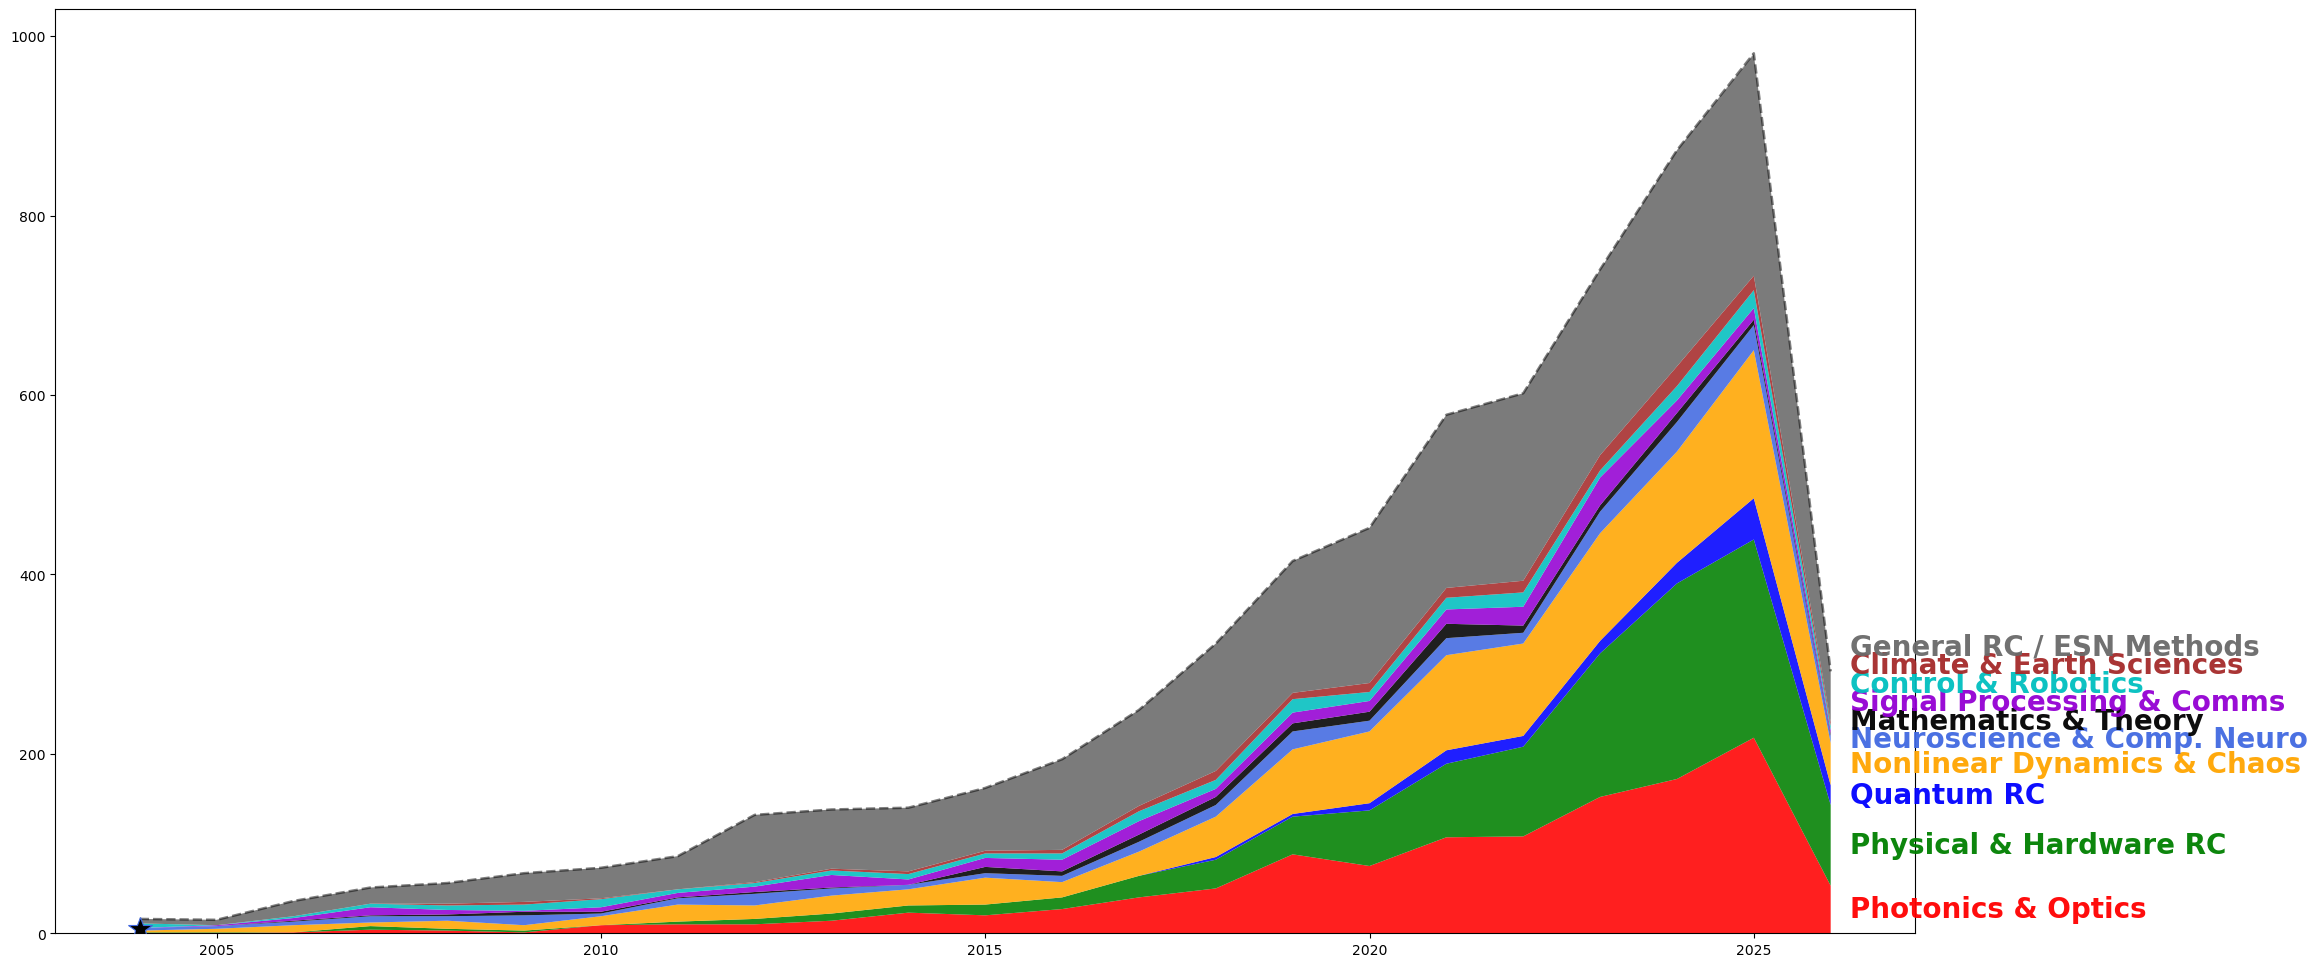

In [108]:
# Run new early-window plots (original plots remain unchanged)
years_early  = list(range(EARLY_WINDOW_END, YEARS[1] + 1))
matrix_early = build_matrix_early_window(papers, order, years_early)
totals_early = matrix_early.sum(axis=0)

print("\nPlotting absolute figure (early window aggregated)...")
plot_absolute_early_window(papers, landmarks, order, matrix_early, years_early, totals_early)

print("\nPlotting normalised figure (early window aggregated)...")
plot_normalised_early_window(papers, landmarks, order, matrix_early, years_early, totals_early)